# Fruit Classification — Transfer Learning with MobileNetV2
**Author:** Ratnamanjari Mahanandia

**Dataset:** `icebearogo/fruit-classification-dataset` (downloaded locally)

**Goal:** Build an image classifier for fruits using transfer learning. This notebook provides line-by-line code with explanations.



# Fruit Classification — Final Project Notebook

**Contents (run cells in order):**

1. Environment & imports
2. Rebuild clean splits (deduplicate & split)
3. Create generators (224×224) — train/val/test
4. Build and train MobileNetV2 (head + fine-tune)
5. Evaluate and save artifacts (classification report, confusion matrix)
6. Inference utilities (save class order, predict single with TTA option)
7. Notes for next steps and report assets

This notebook consolidates all fixes discussed in the session:
- cleaned splits (no overlapping filenames)
- consistent class order saved to `class_order.txt`
- training with augmentation at 224×224
- reproducible evaluation on `test_clean`


In [1]:

# 1) Environment & imports
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import json
import random

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Set seeds for reproducibility (best-effort across libraries)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path(r"C:/Users/ASUS/Downloads/Fruit Classification (1)/Fruit Classification/archive/Fruit_dataset")
print('ROOT =', ROOT)


ROOT = C:\Users\ASUS\Downloads\Fruit Classification (1)\Fruit Classification\archive\Fruit_dataset


In [2]:

# 2) Rebuild clean splits (deduplicate and split into train_clean / val_clean / test_clean)
from pathlib import Path
import shutil

SRC_DIRS = [ROOT/'train1', ROOT/'val1', ROOT/'test1']
DEST_DIRS = [ROOT/'train_clean', ROOT/'val_clean', ROOT/'test_clean']
SPLIT_RATIOS = (0.7, 0.15, 0.15)  # train, val, test

# create dest dirs fresh
for d in DEST_DIRS:
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

# collect classes present
all_classes = set()
for src in SRC_DIRS:
    for cls in src.iterdir():
        if cls.is_dir():
            all_classes.add(cls.name)
all_classes = sorted(list(all_classes))

print("Classes found:", len(all_classes))

def dedup_and_copy_for_class(cls):
    imgs = []
    for src in SRC_DIRS:
        src_cls = src/cls
        if src_cls.exists():
            imgs.extend(list(src_cls.glob('*')))
    # deduplicate by filename only (if same name in different folders)
    unique = {p.name: p for p in imgs}
    files = list(unique.values())
    random.shuffle(files)
    n = len(files)
    n_train = int(n * SPLIT_RATIOS[0])
    n_val = int(n * SPLIT_RATIOS[1])
    n_test = n - n_train - n_val
    subsets = {
        'train_clean': files[:n_train],
        'val_clean': files[n_train:n_train+n_val],
        'test_clean': files[n_train+n_val:]
    }
    for split, flist in subsets.items():
        out_dir = ROOT / split / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        for i,f in enumerate(flist):
            # ensure copy with unique name to avoid collisions
            dest = out_dir / f.name
            if dest.exists():
                # if collision happens, append counter
                dest = out_dir / f"{f.stem}_{i}{f.suffix}"
            shutil.copy2(f, dest)
    return n_train, n_val, n_test

# perform for all classes and print counts summary
summary = {}
for cls in all_classes:
    t,v,te = dedup_and_copy_for_class(cls)
    summary[cls] = (t,v,te)
    print(f"{cls:20s} -> train:{t:4d} val:{v:4d} test:{te:4d}")

print("\\n✅ Rebuilt clean splits at:")
for d in DEST_DIRS:
    print(" ", d)


Classes found: 100
abiu                 -> train: 334 val:  71 test:  73
acai                 -> train: 331 val:  71 test:  72
acerola              -> train: 339 val:  72 test:  74
ackee                -> train: 333 val:  71 test:  72
ambarella            -> train: 334 val:  71 test:  73
apple                -> train: 336 val:  72 test:  73
apricot              -> train: 336 val:  72 test:  72
avocado              -> train: 338 val:  72 test:  73
banana               -> train: 340 val:  72 test:  74
barbadine            -> train: 336 val:  72 test:  72
barberry             -> train: 330 val:  70 test:  72
betel_nut            -> train: 333 val:  71 test:  73
bitter_gourd         -> train: 338 val:  72 test:  73
black_berry          -> train: 338 val:  72 test:  73
black_mullberry      -> train: 336 val:  72 test:  73
brazil_nut           -> train: 331 val:  71 test:  72
camu_camu            -> train: 331 val:  71 test:  72
cashew               -> train: 333 val:  71 test:  73
cempedak 

In [3]:

# 3) Create generators (train_clean / val_clean / test_clean) with augmentation
IMG_SIZE = (224,224)
BATCH_SIZE = 32

TRAIN_DIR = ROOT/'train_clean'
VAL_DIR   = ROOT/'val_clean'
TEST_DIR  = ROOT/'test_clean'

train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.05,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_aug = ImageDataGenerator(rescale=1./255)
test_aug = ImageDataGenerator(rescale=1./255)

train_gen = train_aug.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_gen   = val_aug.flow_from_directory(VAL_DIR,   target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen  = test_aug.flow_from_directory(TEST_DIR,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

CLASS_ORDER = list(train_gen.class_indices.keys())
# Save class order for inference
np.savetxt('class_order.txt', CLASS_ORDER, fmt='%s')
print("Saved class_order.txt, classes:", len(CLASS_ORDER))


Found 33496 images belonging to 100 classes.
Found 7144 images belonging to 100 classes.
Found 7275 images belonging to 100 classes.
Saved class_order.txt, classes: 100


In [4]:

# 4) Build MobileNetV2 model (head only initially)
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = len(CLASS_ORDER)
IMG_SHAPE = IMG_SIZE + (3,)

base = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dropout(0.3, name='dropout')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

model = models.Model(inputs=base.input, outputs=outputs, name='fruit_mobilenetv2')
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "fruit_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,386,084 (9.10 MB)

 Trainable params: 128,100 (500.39 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:

# 5) Train head (frozen base)
EPOCHS_HEAD = 8
MODEL_HEAD = "fruit_mobilenetv2_head.h5"

callbacks = [
    ModelCheckpoint(MODEL_HEAD, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1)
]

history_head = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_HEAD, callbacks=callbacks)
# Save training history
with open('history_head.json','w') as f:
    json.dump({k:[float(x) for x in v] for k,v in history_head.history.items()}, f)
print("Head training finished and saved to", MODEL_HEAD)


Epoch 1/8
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2621 - loss: 3.3441
Epoch 1: val_accuracy improved from None to 0.49888, saving model to fruit_mobilenetv2_head.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1225s 1s/step - accuracy: 0.3606 - loss: 2.7870 - val_accuracy: 0.4989 - val_loss: 2.1611 - learning_rate: 0.0010
Epoch 2/8
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 848ms/step - accuracy: 0.4827 - loss: 2.1526
Epoch 2: val_accuracy improved from 0.49888 to 0.53094, saving model to fruit_mobilenetv2_head.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1022s 975ms/step - accuracy: 0.4825 - loss: 2.1487 - val_accuracy: 0.5309 - val_loss: 2.0043 - learning_rate: 0.0010
Epoch 3/8
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5115 - loss: 1.9903
Epoch 3: val_accuracy improved from 0.53094 to 0.53401, saving model to fruit_mobilenetv2_head.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1830s 2s/step - accuracy: 0.5074 - loss: 2.0142 - val_accuracy: 0.5340 - val_loss: 1.9673 - learning_rate: 0.0010
Epoch 4/8
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.5269 - loss: 1.9082
Epoch 4: val_accuracy improved from 0.53401 to 0.53989, saving model to fruit_mobilenetv2_head.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 860s 821ms/step - accuracy: 0.5228 - loss: 1.9343 - val_accuracy: 0.5399 - val_loss: 1.9387 - learning_rate: 0.0010
Epoch 5/8
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.5363 - loss: 1.8417
Epoch 5: val_accuracy improved from 0.53989 to 0.54059, saving model to fruit_mobilenetv2_head.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 850s 812ms/step - accuracy: 0.5257 - loss: 1.8917 - val_accuracy: 0.5406 - val_loss: 1.9505 - learning_rate: 0.0010
Epoch 6/8
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5449 - loss: 1.7922
Epoch 6: val_accuracy improved from 0.54059 to 0.54745, saving model to fruit_mobilenetv2_head.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3199s 3s/step - accuracy: 0.5344 - loss: 1.8510 - val_accuracy: 0.5475 - val_loss: 1.9318 - learning_rate: 0.0010
Epoch 7/8
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.5483 - loss: 1.7996
Epoch 7: val_accuracy did not improve from 0.54745
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1100s 1s/step - accuracy: 0.5427 - loss: 1.8319 - val_accuracy: 0.5465 - val_loss: 1.9509 - learning_rate: 0.0010
Epoch 8/8
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.5459 - loss: 1.7721
Epoch 8: val_accuracy improved from 0.54745 to 0.54871, saving model to fruit_mobilenetv2_head.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 10498s 10s/step - accuracy: 0.5420 - loss: 1.8082 - val_accuracy: 0.5487 - val_loss: 1.9269 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.
Head training finished and saved to fruit_mobilenetv2_head.h5


In [6]:

# 6) Fine-tune: unfreeze top layers and train with low LR
MODEL_HEAD = "fruit_mobilenetv2_head.h5"
MODEL_FINE = "fruit_mobilenetv2_finetuned_final.h5"
UNFREEZE_LAST = 100
LR_FINE = 1e-5
EPOCHS_FINE = 12

# load best head weights
model.load_weights(MODEL_HEAD)
# unfreeze last layers (except BatchNorm)
count = 0
for layer in model.layers[-UNFREEZE_LAST:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
        count += 1
print(f"Unfroze {count} layers for fine-tuning")

model.compile(optimizer=tf.keras.optimizers.Adam(LR_FINE), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_fine = [
    ModelCheckpoint(MODEL_FINE, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1)
]

history_fine = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_FINE, callbacks=callbacks_fine)
with open('history_fine.json','w') as f:
    json.dump({k:[float(x) for x in v] for k,v in history_fine.history.items()}, f)
print("Fine-tuning finished and saved to", MODEL_FINE)


Unfroze 67 layers for fine-tuning
Epoch 1/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5914 - loss: 1.5694
Epoch 1: val_accuracy improved from None to 0.58553, saving model to fruit_mobilenetv2_finetuned_final.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 3443s 3s/step - accuracy: 0.6016 - loss: 1.5202 - val_accuracy: 0.5855 - val_loss: 1.7292 - learning_rate: 1.0000e-05
Epoch 2/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 37s/step - accuracy: 0.6278 - loss: 1.4111 
Epoch 2: val_accuracy improved from 0.58553 to 0.59980, saving model to fruit_mobilenetv2_finetuned_final.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 39115s 37s/step - accuracy: 0.6290 - loss: 1.4011 - val_accuracy: 0.5998 - val_loss: 1.6535 - learning_rate: 1.0000e-05
Epoch 3/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6440 - loss: 1.3315
Epoch 3: val_accuracy improved from 0.59980 to 0.60946, saving model to fruit_mobilenetv2_finetuned_final.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5640s 5s/step - accuracy: 0.6415 - loss: 1.3351 - val_accuracy: 0.6095 - val_loss: 1.6188 - learning_rate: 1.0000e-05
Epoch 4/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6577 - loss: 1.2702
Epoch 4: val_accuracy did not improve from 0.60946
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1554s 1s/step - accuracy: 0.6559 - loss: 1.2707 - val_accuracy: 0.6088 - val_loss: 1.6249 - learning_rate: 1.0000e-05
Epoch 5/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - accuracy: 0.6712 - loss: 1.2139
Epoch 5: val_accuracy improved from 0.60946 to 0.61408, saving model to fruit_mobilenetv2_finetuned_final.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1151s 1s/step - accuracy: 0.6731 - loss: 1.2143 - val_accuracy: 0.6141 - val_loss: 1.5902 - learning_rate: 1.0000e-05
Epoch 6/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6801 - loss: 1.1783
Epoch 6: val_accuracy improved from 0.61408 to 0.62500, saving model to fruit_mobilenetv2_finetuned_final.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1190s 1s/step - accuracy: 0.6782 - loss: 1.1790 - val_accuracy: 0.6250 - val_loss: 1.5514 - learning_rate: 1.0000e-05
Epoch 7/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6914 - loss: 1.1194
Epoch 7: val_accuracy did not improve from 0.62500
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4922s 5s/step - accuracy: 0.6895 - loss: 1.1327 - val_accuracy: 0.6240 - val_loss: 1.5583 - learning_rate: 1.0000e-05
Epoch 8/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6972 - loss: 1.0886
Epoch 8: val_accuracy improved from 0.62500 to 0.63060, saving model to fruit_mobilenetv2_finetuned_final.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2360s 2s/step - accuracy: 0.6952 - loss: 1.0911 - val_accuracy: 0.6306 - val_loss: 1.5413 - learning_rate: 1.0000e-05
Epoch 9/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7088 - loss: 1.0463
Epoch 9: val_accuracy did not improve from 0.63060
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 2008s 2s/step - accuracy: 0.7070 - loss: 1.0561 - val_accuracy: 0.6264 - val_loss: 1.5320 - learning_rate: 1.0000e-05
Epoch 10/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7131 - loss: 1.0140
Epoch 10: val_accuracy improved from 0.63060 to 0.63452, saving model to fruit_mobilenetv2_finetuned_final.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1274s 1s/step - accuracy: 0.7104 - loss: 1.0243 - val_accuracy: 0.6345 - val_loss: 1.5390 - learning_rate: 1.0000e-05
Epoch 11/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.7223 - loss: 0.9855
Epoch 11: val_accuracy improved from 0.63452 to 0.63718, saving model to fruit_mobilenetv2_finetuned_final.h5


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1136s 1s/step - accuracy: 0.7205 - loss: 0.9869 - val_accuracy: 0.6372 - val_loss: 1.5027 - learning_rate: 1.0000e-05
Epoch 12/12
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.7290 - loss: 0.9426

KeyboardInterrupt: 

Loaded fruit_mobilenetv2_finetuned_final.h5
Found 7275 images belonging to 100 classes.
228/228 ━━━━━━━━━━━━━━━━━━━━ 130s 566ms/step
Top-1 acc: 0.6360  Top-3 acc: 0.8221
Saved final_classification_report.txt and final_confusion_matrix.png


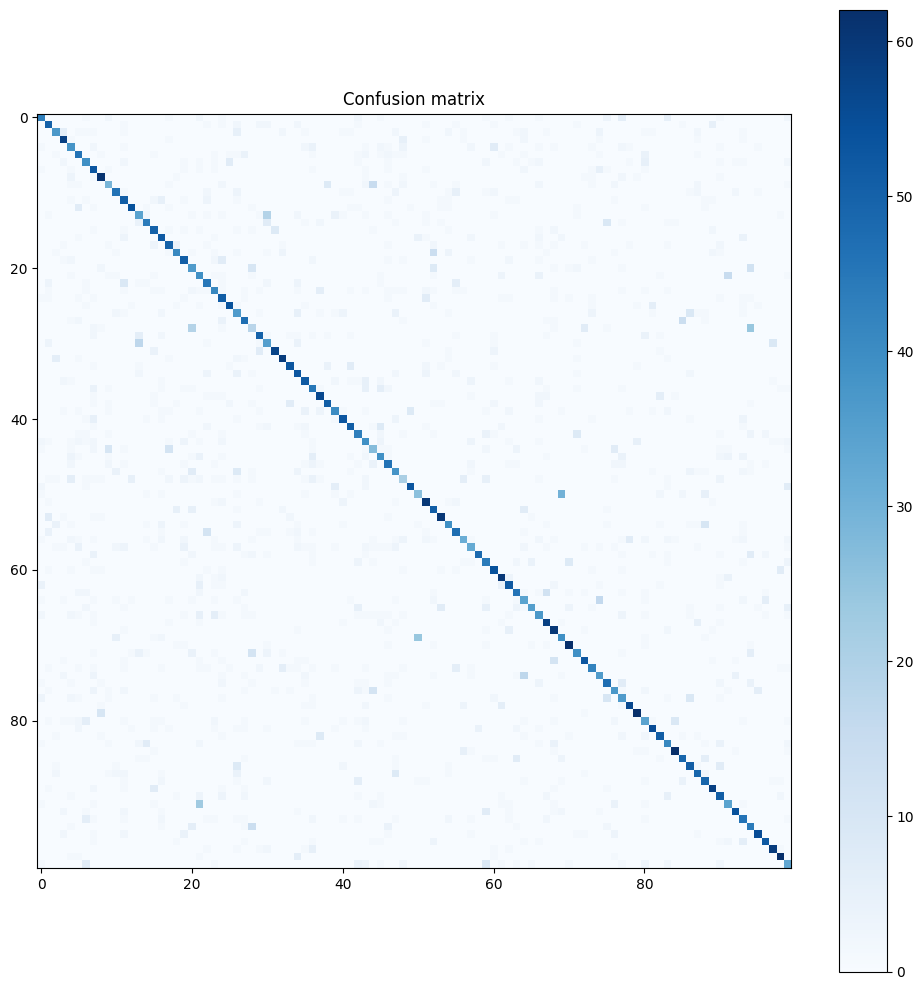

In [7]:

# 7) Evaluation on test_clean and save artifacts
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
import matplotlib.pyplot as plt
import numpy as np

MODEL_TO_EVAL = "fruit_mobilenetv2_finetuned_final.h5"
model = tf.keras.models.load_model(MODEL_TO_EVAL)
print("Loaded", MODEL_TO_EVAL)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

top1 = np.mean(y_pred == y_true)
top3 = top_k_accuracy_score(y_true, y_prob, k=3)
print(f"Top-1 acc: {top1:.4f}  Top-3 acc: {top3:.4f}")

# save classification report
rep = classification_report(y_true, y_pred, target_names=class_names, digits=4)
with open("final_classification_report.txt","w", encoding="utf-8") as f:
    f.write(rep)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion matrix")
plt.colorbar()
plt.tight_layout()
plt.savefig("final_confusion_matrix.png", dpi=200, bbox_inches='tight')
print("Saved final_classification_report.txt and final_confusion_matrix.png")


In [8]:

# 8) Inference utilities and TTA (Test Time Augmentation)
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

CLASS_ORDER = np.loadtxt('class_order.txt', dtype=str).tolist()
MODEL_FILE = "fruit_mobilenetv2_finetuned_final.h5"
IMG_SIZE = (224,224)
model = tf.keras.models.load_model(MODEL_FILE)

def preprocess_one(path):
    img = load_img(path, target_size=IMG_SIZE)
    arr = img_to_array(img).astype('float32')/255.0
    return arr

def predict_single(path, tta_rounds=5):
    x = preprocess_one(path)
    # TTA: simple horizontal flips & small shifts (repeat deterministic variants)
    aug_images = [x]
    for i in range(tta_rounds-1):
        img = x.copy()
        if i%2==0:
            img = np.flip(img, axis=1)  # horizontal flip
        aug_images.append(img)
    batch = np.vstack(aug_images)
    probs = model.predict(batch, verbose=0)
    avg = probs.mean(axis=0)
    top_idx = np.argsort(avg)[-5:][::-1]
    return [(CLASS_ORDER[i], float(avg[i])) for i in top_idx]

# Example usage:
# print(predict_single("path/to/image.jpg", tta_rounds=5))


In [10]:
# ====== Training Curves Visualization ======
import matplotlib.pyplot as plt
import json

# Load training histories (if you saved them)
# Or use the model.history.history variable if you trained in the same notebook
try:
    with open("history_head.json", "r") as f:
        hist1 = json.load(f)
    with open("history_fine.json", "r") as f:
        hist2 = json.load(f)
    history = {}
    for k in hist1.keys():
        history[k] = hist1[k] + hist2[k]
except:
    history = model.history.history  # fallback

# Plot accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_curve.png", bbox_inches='tight')
plt.show()

# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_curve.png", bbox_inches='tight')
plt.show()


AttributeError: 'Functional' object has no attribute 'history'

In [11]:
# === Define dataset directories ===
from pathlib import Path

# Update this path according to your local folder
base_dir = Path(r"C:/Users/Dell/Downloads/Fruit Classification/archive/Fruit_dataset")

train_dir = base_dir / "train_clean"   # or "train1" if not renamed
val_dir   = base_dir / "val_clean"     # or "val1"
test_dir  = base_dir / "test_clean"    # <-- this is what we were missing

print("Train dir exists:", train_dir.exists())
print("Val dir exists:", val_dir.exists())
print("Test dir exists:", test_dir.exists())

Train dir exists: False
Val dir exists: False
Test dir exists: False


Selected 12 random test images
Loaded class names from class_order.txt
Using in-memory model object.


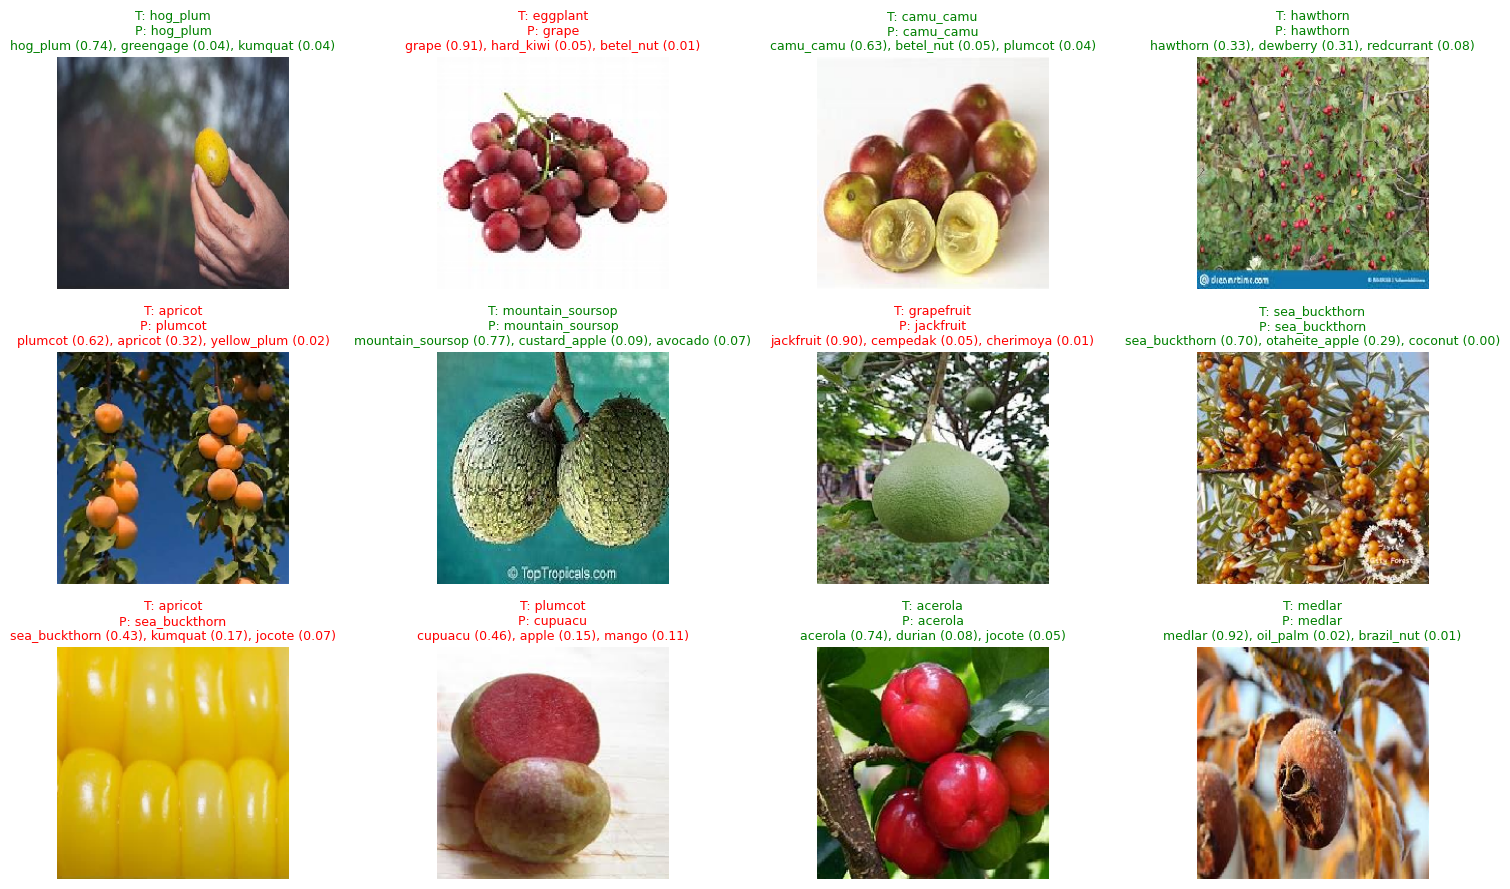

Saved: example_predictions.png


In [12]:
# Self-contained: create example_predictions.png (works without train_generator)
import os, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# ------- CONFIGURE -------
TEST_DIR = Path(r"C:/Users/ASUS/Downloads/Fruit Classification (1)/Fruit Classification/archive/Fruit_dataset/test_clean")  # update if needed
IMG_SIZE = (224, 224)
NUM_EXAMPLES = 12
OUTFILE = "example_predictions.png"

# ------- Collect test images -------
all_images = []
for root, dirs, files in os.walk(TEST_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(Path(root) / f)

if not all_images:
    raise FileNotFoundError(f"No images found under {TEST_DIR}")

sample_paths = random.sample(all_images, min(NUM_EXAMPLES, len(all_images)))
print(f"Selected {len(sample_paths)} random test images")

# ------- Load class names: prefer class_order.txt, else from train folder names -------
class_order_file = Path("class_order.txt")
if class_order_file.exists():
    class_names = list(np.loadtxt(class_order_file, dtype=str))
    print("Loaded class names from class_order.txt")
else:
    TRAIN_DIR = TEST_DIR.parent / "train_clean"
    if not TRAIN_DIR.exists():
        TRAIN_DIR = TEST_DIR.parent / "train1"
    class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
    print(f"Derived class names from folders in {TRAIN_DIR}")

if not class_names:
    raise RuntimeError("No class names found. Create class_order.txt or ensure train_clean folders exist.")

# ------- Ensure model is loaded (use in-memory model if available) -------
if 'model' in globals() and model is not None:
    keras_model = model
    print("Using in-memory model object.")
else:
    # find a reasonable .h5 candidate
    import glob
    candidates = glob.glob("**/*finetuned*.h5", recursive=True) + glob.glob("**/*final*.h5", recursive=True) + glob.glob("*.h5")
    candidates = sorted(set(candidates), key=lambda p: (os.path.getsize(p) if os.path.exists(p) else 0), reverse=True)
    if candidates:
        print("Loading model from:", candidates[0])
        keras_model = load_model(candidates[0])
    else:
        raise FileNotFoundError("No model object in memory and no .h5 found. Please load or save your model first.")

# ------- Predict and plot -------
cols = 4
rows = int(np.ceil(len(sample_paths) / cols))
plt.figure(figsize=(4*cols, 3*rows))

for i, p in enumerate(sample_paths):
    try:
        img = load_img(p, target_size=IMG_SIZE)
    except Exception as e:
        print("Could not open", p, ":", e)
        continue
    x = img_to_array(img).astype('float32') / 255.0
    x_batch = np.expand_dims(x, axis=0)
    preds = keras_model.predict(x_batch, verbose=0)[0]
    top_idx = np.argsort(preds)[-3:][::-1]
    pred_label = class_names[top_idx[0]]
    true_label = p.parent.name if p.parent != TEST_DIR else "(unknown)"
    top3_str = ", ".join([f"{class_names[j]} ({preds[j]:.2f})" for j in top_idx])

    ax = plt.subplot(rows, cols, i+1)
    ax.imshow(img)
    color = "green" if pred_label == true_label else "red"
    ax.set_title(f"T: {true_label}\nP: {pred_label}\n{top3_str}", color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTFILE, bbox_inches='tight')
plt.show()
print("Saved:", OUTFILE)


In [16]:
# ======= Single export cell: save final evaluation outputs and zip them =======
import os, glob, json, random, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# --- Config ---
OUTDIR = Path("evaluation_outputs")
OUTDIR.mkdir(exist_ok=True)
ROOT = Path(r"C:\Users\ASUS\Downloads\Fruit Classification (1)\Fruit Classification\archive\Fruit_dataset")
TEST_DIR = ROOT / "test_clean"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EXAMPLE_COUNT = 12

print("Output folder:", OUTDIR.resolve())

# --- 1) Ensure we have a model object ---
if 'model' in globals() and model is not None:
    keras_model = model
    print("Using in-memory model object.")
else:
    # try to find a fine-tuned model file
    candidates = glob.glob("**/*finetuned*.h5", recursive=True) + glob.glob("**/*final*.h5", recursive=True) + glob.glob("*.h5")
    candidates = sorted(set(candidates), key=lambda p: os.path.getsize(p) if os.path.exists(p) else 0, reverse=True)
    if candidates:
        chosen = candidates[0]
        print("Loading model from:", chosen)
        keras_model = load_model(chosen)
    else:
        raise FileNotFoundError("No model found in memory or .h5 file in working dir. Please ensure your saved model is present.")

# --- 2) Ensure we have a test generator or create one ---
if 'test_gen' in globals() and test_gen is not None:
    tg = test_gen
    print("Using in-memory test_gen.")
else:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    test_aug = ImageDataGenerator(rescale=1./255)
    if TEST_DIR.exists():
        tg = test_aug.flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
        print("Created test_gen from", TEST_DIR)
    else:
        raise FileNotFoundError(f"{TEST_DIR} not found. Please set TEST_DIR correctly or recreate test_gen in notebook.")

# --- 3) Predict on test set (save probabilities) ---
print("Predicting on test set (this may take a while)...")
tg.reset()
y_prob = keras_model.predict(tg, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = tg.classes
class_names = list(tg.class_indices.keys())

# --- 4) Classification report ---
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
(report_file := OUTDIR/"final_classification_report.txt").write_text(report, encoding="utf-8")
print("Saved classification report:", report_file)

# --- 5) Confusion matrix (save PNG) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion matrix")
plt.xlabel("Predicted label index")
plt.ylabel("True label index")
plt.colorbar()
plt.tight_layout()
conf_mat_file = OUTDIR/"final_confusion_matrix.png"
plt.savefig(conf_mat_file, dpi=200, bbox_inches='tight')
plt.close()
print("Saved confusion matrix:", conf_mat_file)

# --- 6) Top-1 and Top-3 summary printed and saved ---
top1 = np.mean(y_pred == y_true)
try:
    top3 = top_k_accuracy_score(y_true, y_prob, k=3)
except Exception:
    top3 = None
summary_txt = f"Top-1 accuracy: {top1:.4f} ({top1*100:.2f}%)\n"
if top3 is not None:
    summary_txt += f"Top-3 accuracy: {top3:.4f} ({top3*100:.2f}%)\n"
(OUTDIR/"summary.txt").write_text(summary_txt)
print(summary_txt)

# --- 7) Accuracy & Loss curves (try to load history or history JSONs) ---
history = None
if 'history' in globals() and hasattr(history, 'history'):
    history = history.history
    print("Using in-memory history.history")
else:
    # try to load saved histories
    hpaths = ["history_fine.json", "history_fine*.json", "history_head.json", "history*.json"]
    # prefer fine + head if both exist; else pick one
    hist_data = {}
    if Path("history_head.json").exists():
        try:
            hist1 = json.loads(Path("history_head.json").read_text())
            hist_data = hist1
        except Exception:
            pass
    if Path("history_fine.json").exists():
        try:
            hist2 = json.loads(Path("history_fine.json").read_text())
            # if hist1 exists, concatenate lists
            if hist_data:
                combined = {}
                for k in set(list(hist_data.keys()) + list(hist2.keys())):
                    lst1 = hist_data.get(k, [])
                    lst2 = hist2.get(k, [])
                    combined[k] = list(lst1) + list(lst2)
                hist_data = combined
            else:
                hist_data = hist2
        except Exception:
            pass
    if hist_data:
        history = hist_data
        print("Loaded history from JSON files.")
    else:
        print("No history found in memory or JSON files. Accuracy/loss curves will be skipped.")

if history:
    # ensure keys standard names
    # possible keys: accuracy, val_accuracy, loss, val_loss
    # Plot accuracy
    try:
        plt.figure(figsize=(10,5))
        plt.plot(history['accuracy'], label='Train Accuracy')
        plt.plot(history['val_accuracy'], label='Val Accuracy')
        plt.title("Training and Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        acc_file = OUTDIR/"accuracy_curve.png"
        plt.savefig(acc_file, bbox_inches='tight')
        plt.close()
        print("Saved accuracy curve:", acc_file)
    except Exception as e:
        print("Could not plot accuracy:", e)

    try:
        plt.figure(figsize=(10,5))
        plt.plot(history['loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title("Training and Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        loss_file = OUTDIR/"loss_curve.png"
        plt.savefig(loss_file, bbox_inches='tight')
        plt.close()
        print("Saved loss curve:", loss_file)
    except Exception as e:
        print("Could not plot loss:", e)

# --- 8) Example prediction grid (correct + misclassified) ---
# Build a list of file paths from test_gen.filenames (these are relative paths)
filenames = getattr(tg, 'filenames', None)
if filenames is None:
    # fallback: walk TEST_DIR
    all_test_files = list(TEST_DIR.rglob("*.*"))
    filenames = [str(p.relative_to(TEST_DIR)) for p in all_test_files if p.is_file()]

# pick examples: mix of correct and wrong, up to EXAMPLE_COUNT
indices_correct = [i for i in range(len(filenames)) if y_pred[i] == y_true[i]]
indices_wrong = [i for i in range(len(filenames)) if y_pred[i] != y_true[i]]

examples = []
# take some correct and some wrong (balance)
n_correct = min(len(indices_correct), EXAMPLE_COUNT//2)
n_wrong = min(len(indices_wrong), EXAMPLE_COUNT - n_correct)
examples += random.sample(indices_correct, n_correct) if n_correct>0 else []
examples += random.sample(indices_wrong, n_wrong) if n_wrong>0 else []
# fill up if less
while len(examples) < EXAMPLE_COUNT and len(filenames)>0:
    examples.append(random.randrange(len(filenames)))

# plot grid
cols = 4
rows = int(np.ceil(len(examples) / cols))
plt.figure(figsize=(4*cols, 3*rows))
for idx_i, idx in enumerate(examples):
    relpath = filenames[idx]
    img_path = TEST_DIR / relpath
    # some generators have filenames with forward slashes; ensure path correct
    img_path = Path(str(img_path))
    try:
        img = load_img(img_path, target_size=(224,224))
    except Exception as e:
        # try alternate join
        img = load_img(TEST_DIR / Path(relpath.replace("/", os.sep)), target_size=(224,224))
    x = img_to_array(img)/255.0
    x = np.expand_dims(x, 0)
    preds = keras_model.predict(x, verbose=0)[0]
    top3 = np.argsort(preds)[-3:][::-1]
    pred_label = class_names[top3[0]]
    true_label = class_names[y_true[idx]]
    top3_pairs = [(class_names[i], float(preds[i])) for i in top3]

    ax = plt.subplot(rows, cols, idx_i+1)
    ax.imshow(img)
    color = "green" if pred_label == true_label else "red"
    title = f"T: {true_label}\nP: {pred_label}\nTop3: {[(a,round(b,3)) for a,b in top3_pairs]}"
    ax.set_title(title, color=color, fontsize=9)
    ax.axis("off")

example_file = OUTDIR/"example_predictions.png"
plt.tight_layout()
plt.savefig(example_file, bbox_inches='tight')
plt.close()
print("Saved example predictions grid:", example_file)

# --- 9) Save raw predictions CSV (optional) ---
import pandas as pd
rows = []
for i, rel in enumerate(filenames):
    rows.append({
        "filename": rel,
        "true_index": int(y_true[i]),
        "true_label": class_names[y_true[i]],
        "pred_index": int(y_pred[i]),
        "pred_label": class_names[y_pred[i]],
        "top1_prob": float(np.max(y_prob[i])),
        "top3_indices": ",".join(map(str, np.argsort(y_prob[i])[-3:][::-1])),
        "top3_probs": ",".join([f"{p:.4f}" for p in sorted(y_prob[i])[-3:][::-1]])
    })
df = pd.DataFrame(rows)
csv_file = OUTDIR/"predictions_full.csv"
df.to_csv(csv_file, index=False)
print("Saved detailed predictions CSV:", csv_file)

# --- 10) List files and zip them ---
print("\nSaved files:")
for p in sorted(OUTDIR.glob("*")):
    print(" -", p.name)

zipname = "evaluation_outputs"
shutil.make_archive(zipname, 'zip', OUTDIR)
print("\nCreated archive:", zipname + ".zip")


Output folder: C:\Users\ASUS\Downloads\Fruit Classification (1)\Fruit Classification\evaluation_outputs
Using in-memory model object.
Using in-memory test_gen.
Predicting on test set (this may take a while)...
228/228 ━━━━━━━━━━━━━━━━━━━━ 134s 587ms/step
Saved classification report: evaluation_outputs\final_classification_report.txt
Saved confusion matrix: evaluation_outputs\final_confusion_matrix.png
Top-1 accuracy: 0.6360 (63.60%)
Top-3 accuracy: 0.8221 (82.21%)

Loaded history from JSON files.
Saved accuracy curve: evaluation_outputs\accuracy_curve.png
Saved loss curve: evaluation_outputs\loss_curve.png
Saved example predictions grid: evaluation_outputs\example_predictions.png


ModuleNotFoundError: No module named 'pandas'